# Clustering

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, accuracy_score

OUT_DIR = Path("../outputs")
df = pd.read_csv(OUT_DIR / "inventory.csv")
X = np.load(OUT_DIR / "features.npy")
mask = df["split"] == "labeled"                 # les 100 fortement labellisées
print(X.shape, "| labellisées :", mask.sum())

(1506, 2048) | labellisées : 100


In [2]:
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=50, random_state=0)
X_pca = pca.fit_transform(X_scaled)
print("Variance expliquée par 50 composantes :", pca.explained_variance_ratio_.sum().round(3))

Variance expliquée par 50 composantes : 0.461


In [3]:
km = KMeans(n_clusters=2, n_init=10, random_state=0)
df["cluster"] = km.fit_predict(X_pca)

y_true = df.loc[mask, "label"].values
c_lab  = df.loc[mask, "cluster"].values

print("ARI (K-Means, sur les 100 labellisées) :", round(adjusted_rand_score(y_true, c_lab), 3))
print("\nCroisement cluster × vrai label :")
print(pd.crosstab(df.loc[mask, "label"], df.loc[mask, "cluster"]))

ARI (K-Means, sur les 100 labellisées) : 0.124

Croisement cluster × vrai label :
cluster   0   1
label          
cancer   20  30
normal    2  48


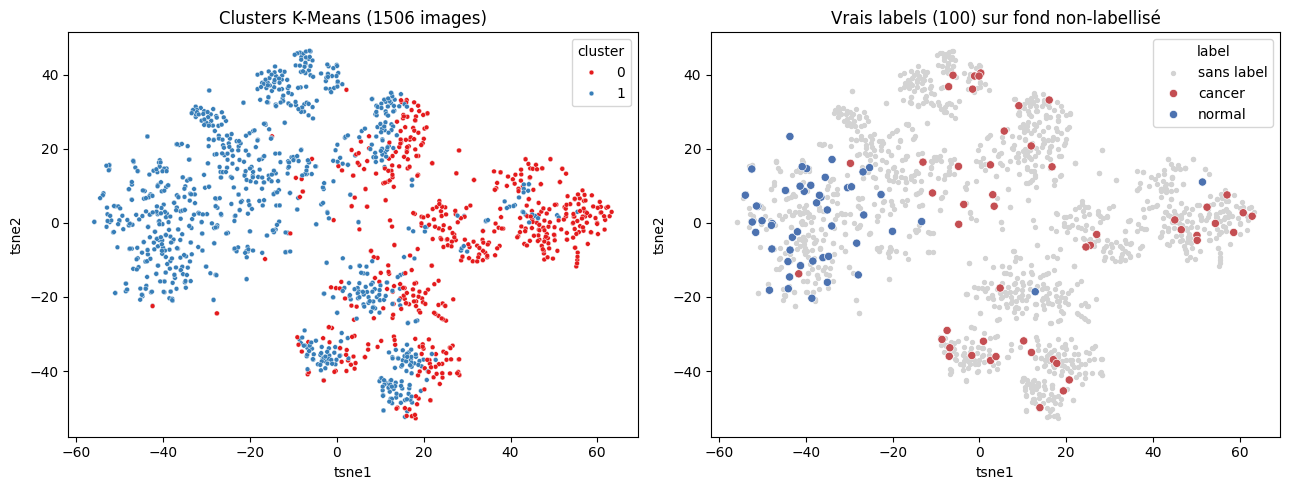

In [4]:
X_2d = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(X_pca)
df["tsne1"], df["tsne2"] = X_2d[:, 0], X_2d[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="tsne1", y="tsne2", hue="cluster", palette="Set1", s=12, ax=ax[0])
ax[0].set_title("Clusters K-Means (1506 images)")

ax[1].scatter(df[~mask]["tsne1"], df[~mask]["tsne2"], c="lightgray", s=8, label="sans label")
sns.scatterplot(data=df[mask], x="tsne1", y="tsne2", hue="label",
                palette={"normal": "#4c72b0", "cancer": "#c44e52"}, s=35, ax=ax[1])
ax[1].set_title("Vrais labels (100) sur fond non-labellisé")
plt.tight_layout(); plt.show()

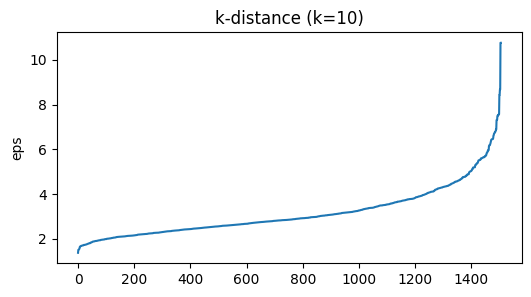

DBSCAN -> clusters : 15 | points 'bruit' : 293
ARI DBSCAN : 0.181


In [5]:
# courbe des k-distances pour repérer le "coude" -> eps
from sklearn.neighbors import NearestNeighbors
d = np.sort(NearestNeighbors(n_neighbors=10).fit(X_2d).kneighbors(X_2d)[0][:, -1])
plt.figure(figsize=(6, 3)); plt.plot(d); plt.title("k-distance (k=10)"); plt.ylabel("eps"); plt.show()

db = DBSCAN(eps=3.0, min_samples=10).fit(X_2d)   # ajuste eps selon le coude ci-dessus
df["dbscan"] = db.labels_
n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print("DBSCAN -> clusters :", n_cl, "| points 'bruit' :", int((db.labels_ == -1).sum()))
print("ARI DBSCAN :", round(adjusted_rand_score(y_true, df.loc[mask, "dbscan"].values), 3))

In [6]:
# numéro de cluster -> classe, via vote majoritaire sur les SEULES labellisées
mapping = df[mask].groupby("cluster")["label"].agg(lambda s: s.value_counts().idxmax())
print("Mapping cluster -> classe :", mapping.to_dict())

pred_lab = df.loc[mask, "cluster"].map(mapping)
print("Accuracy du clustering sur les 100 labellisées :",
      round(accuracy_score(df.loc[mask, "label"], pred_lab), 3))

df["weak_label"] = df["cluster"].map(mapping)

# >>> jeux STRICTEMENT séparés <
strong = df[mask][["path", "label"]].rename(columns={"label": "y"})
weak   = df[~mask][["path", "weak_label"]].rename(columns={"weak_label": "y"})
strong.to_csv(OUT_DIR / "strong_labeled.csv", index=False)
weak.to_csv(OUT_DIR / "weak_labeled.csv", index=False)

print("\nFortement labellisé :", len(strong), "| Faiblement labellisé :", len(weak))
print(weak["y"].value_counts())

Mapping cluster -> classe : {0: 'cancer', 1: 'normal'}
Accuracy du clustering sur les 100 labellisées : 0.68

Fortement labellisé : 100 | Faiblement labellisé : 1406
y
normal    892
cancer    514
Name: count, dtype: int64
